# CS336 Assignment 5 — GRPO experiments

GRPO on GSM8K with `allenai/OLMo-2-0425-1B`. A training process on GPU 0 holds the policy, and a vLLM server on GPU 1 produces the rollouts, with policy weights synced to vLLM before every rollout step. Every run uses 2× RTX 4090.

**Shared setup** (unless a section says otherwise): `r1_zero` prompt, 200 rollout steps, 256 rollouts per step (32 questions × group size 8), sampling temperature 1.0, AdamW at LR 1e-5 with β = (0.9, 0.95), no weight decay, and grad clipping at 1.0. The validation reward is the mean answer reward on 1,024 fixed GSM8K test questions, sampled at temperature 1.0, every 10 steps.

Run data comes from wandb (`jerzhou-personal-team/cs336-assignment-5`). The notebook covers:

1. **Learning-rate sweep.** 1e-5 works. 3e-6 barely moves in 200 steps, and 3e-5 and above collapse the policy within the first 10 steps.
2. **Loss normalization.** Per-sequence mean vs. a constant normalizer (Dr. GRPO style).
3. **Advantage normalization.** Dividing by the group std, by the group mean, or by nothing, plus no baseline at all.
4. **Off-policy training.** 32 optimizer steps per rollout batch instead of 1, with no importance weighting, unclipped importance weights, or GRPO-Clip.
5. **Sample rollouts** from the training logs.

A note on noise: with 1,024 questions, one validation measurement has a standard error of about ±0.016. Seed-to-seed (and even same-seed) variation is larger than that; see the noise check below.

In [1]:
import functools
import re
import tempfile
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wandb

PROJECT = "jerzhou-personal-team/cs336-assignment-5"
api = wandb.Api()
FIG_DIR = Path("figures")  # PNGs used by the README
FIG_DIR.mkdir(exist_ok=True)

# --- plot style: recessive axes, thin lines, ink-colored text ---
INK, INK_2, MUTED, GRID = "#0b0b0b", "#52514e", "#8a8984", "#e6e5e1"
# Categorical palette (validated for color-vision deficiency in this fixed order).
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
REF = "#a3a29c"  # reference / baseline runs

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK_2,
    "axes.titlecolor": INK,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "xtick.color": INK_2,
    "ytick.color": INK_2,
    "lines.linewidth": 1.8,
    "legend.frameon": False,
    "legend.fontsize": 9,
    "font.size": 10,
})

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


## Which runs are used

The wandb project has 67 runs; most of the early ones crashed at startup while the training loop was being debugged. The runs below were chosen per experiment. Any run that is cut short is drawn **dashed** and ends in an **×**.

Many runs marked `failed` trained correctly until they died: several hit **CUDA OOM** on the 24 GB training GPU partway through, and several crashed when `torch.save` ran out of disk while writing a checkpoint. Their curves are valid up to that point.

In [2]:
# run id -> label, grouped by experiment.
LR_SWEEP = {  # on-policy (1 optimizer step per rollout batch), sequence-normalized loss, std advantages
    "h9lpde12": (3e-6, 300),  # silver-deluge-24
    "mt54tygl": (1e-5, 512),  # efficient-flower-15 (seed 1)
    "91t49rfo": (1e-5, 300),  # gentle-firefly-25   (killed at 120)
    "ypkjucun": (3e-5, 300),  # trim-cloud-26       (disk full at 100)
    "q1dxpljh": (1e-4, 512),  # hardy-resonance-18  (killed at 40)
}  # value: (lr, sampling max tokens)

LOSS_NORM = {  # on-policy, LR 1e-5, std advantages, max 300 tokens (except efficient-flower-15: 512)
    "sequence (per-seq mean)": ["91t49rfo", "mt54tygl"],          # gentle-firefly-25, efficient-flower-15
    "constant, C = 76,800":    ["6evunf3n", "0h0ivznr"],          # silvery-planet-34, solar-star-35
}

ADV_NORM = {  # on-policy, LR 1e-5, max 300 tokens, constant loss normalization C = 76,800
    "(r − mean) / std":     ["6evunf3n", "0h0ivznr"],  # silvery-planet-34, solar-star-35
    "r − mean":             ["6w2i0hfj", "0qkxbndf"],  # true-oath-36, treasured-haze-37
    "(r − mean) / mean":    ["myqnd1k2", "ad5bzmsp"],  # breezy-wood-42, dazzling-lake-43
    "r (no baseline)":      ["v8wxybrl", "e3imy4fn"],  # azure-sound-38, unique-feather-39
}

ON_POLICY_REF = ["91t49rfo", "b67jmns5"]  # same settings as the off-policy runs, but 1 optimizer step per rollout batch
OFF_POLICY = {  # train batch 8 -> 32 optimizer steps per rollout batch; LR 1e-5, max 300 tokens, sequence norm, std adv
    "no importance weights": ["44zbim7e", "gkph4mty", "3qzxiuhz", "hgghvr6e", "ek446a6g"],
    # peachy-snowflake-47, autumn-energy-48, smart-bird-49, spring-sun-51, eager-music-52
    "importance weights, no clip": ["1b9r9sta", "hnnqod68", "xcf03az5", "8270x1dq", "v5883raw"],
    # hopeful-sponge-55, olive-bush-56, stoic-grass-57, revived-lake-58, expert-star-59
    "GRPO-Clip (ε = 0.2)": ["gw7ua12n", "vq9qrfxa", "cgoxj481", "olvw2g7r", "2grnvy1p", "xe3ex7i4"],
    # cool-blaze-60, cerulean-river-61, vocal-thunder-62, woven-durian-63, usual-flower-66, rural-smoke-67
}

# Noise checks: identical configs.
SEED0_PAIR = ("9g2g6lod", "li3gh6v8")  # atomic-snowflake-8, autumn-firebrand-14: LR 1e-5, 512 tokens, seed 0
SEED20_PAIR = ("xjtjaubt", "ad5bzmsp")  # sandy-voice-41, dazzling-lake-43: mean-normalized advantages, seed 20

In [3]:
@dataclass
class Run:
    id: str
    name: str
    state: str
    config: dict
    runtime_s: float
    train: pd.DataFrame  # index: step
    val: pd.DataFrame    # index: step; columns: val/reward, val/format_reward, val/mean_response_len

    @property
    def last_step(self) -> int:
        return int(self.val.index.max())

    @property
    def complete(self) -> bool:
        return self.last_step >= self.config["num_rollout_steps"]


@functools.cache
def load(run_id: str) -> Run:
    r = api.run(f"{PROJECT}/{run_id}")
    h = r.history(samples=100_000).set_index("_step").sort_index()
    val_cols = [c for c in ["val/reward", "val/format_reward", "val/mean_response_len"] if c in h]
    train_cols = [c for c in h if c.startswith("train/")]
    val = h[val_cols].dropna(subset=["val/reward"])
    return Run(run_id, r.name, r.state, dict(r.config), r.summary.get("_runtime", np.nan), h[train_cols].dropna(how="all"), val)


def plot_curve(ax, run: Run, col: str, color, label=None, **kw):
    # Solid if the run completed, dashed + "x" at the last point if it was cut short.
    s = run.val[col].dropna()
    ls = "-" if run.complete else "--"
    ax.plot(s.index, s.values, color=color, ls=ls, label=label, **kw)
    if not run.complete:
        ax.plot(s.index[-1], s.values[-1], marker="x", ms=7, mew=2, color=color, ls="none", alpha=kw.get("alpha", 1))


def savefig(fig, name):
    fig.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")


all_ids = {*LR_SWEEP, *ON_POLICY_REF, *SEED0_PAIR, *SEED20_PAIR}
for group in [LOSS_NORM, ADV_NORM, OFF_POLICY]:
    all_ids |= {rid for ids in group.values() for rid in ids}
runs = {rid: load(rid) for rid in sorted(all_ids)}

def describe(r: Run) -> dict:
    c = r.config
    norm = "sequence" if c["loss_normalization"] == "sequence" else f"constant ({c['normalization_constant']})"
    steps_per_rollout = c["rollout_batch_size"] // c["train_batch_size"]
    return dict(run=r.name, lr=c["lr"], max_tok=c["sampling_max_tokens"], loss_norm=norm,
                adv=f"{c['baseline']}/{c['advantage_normalizer']}", opt_steps_per_rollout=steps_per_rollout,
                importance=c["importance_reweighting_method"], seed=c["seed"],
                steps=f"{r.last_step}/{c['num_rollout_steps']}", final_val=round(r.val["val/reward"].iloc[-1], 3),
                wandb_state=r.state)

pd.DataFrame([describe(r) for r in sorted(runs.values(), key=lambda r: int(r.name.rsplit("-", 1)[1]))]).style.hide(axis="index").format(
    {"lr": "{:.0e}", "final_val": "{:.3f}"})

run,lr,max_tok,loss_norm,adv,opt_steps_per_rollout,importance,seed,steps,final_val,wandb_state
atomic-snowflake-8,1e-05,512,sequence,mean/std,1,none,0,170/200,0.431,killed
autumn-firebrand-14,1e-05,512,sequence,mean/std,1,none,0,180/200,0.456,crashed
efficient-flower-15,1e-05,512,sequence,mean/std,1,none,1,200/200,0.439,finished
hardy-resonance-18,1e-04,512,sequence,mean/std,1,none,0,40/200,0.000,killed
silver-deluge-24,3e-06,300,sequence,mean/std,1,none,0,200/200,0.030,finished
gentle-firefly-25,1e-05,300,sequence,mean/std,1,none,0,120/200,0.436,killed
trim-cloud-26,3e-05,300,sequence,mean/std,1,none,0,100/200,0.000,failed
cool-lake-27,1e-05,300,sequence,mean/std,1,none,0,50/200,0.359,killed
silvery-planet-34,1e-05,300,constant (76800),mean/std,1,none,1,200/200,0.443,finished
solar-star-35,1e-05,300,constant (76800),mean/std,1,none,1940,100/200,0.430,failed


In [4]:
# Noise check: how much do runs with identical config and seed differ?
for a_id, b_id in [SEED0_PAIR, SEED20_PAIR]:
    a, b = runs[a_id].val["val/reward"], runs[b_id].val["val/reward"]
    common = a.index.intersection(b.index)
    late = common[common >= 50]
    diff = (a[late] - b[late]).abs()
    print(f"{runs[a_id].name} vs {runs[b_id].name} (same config + seed), steps 50–{late.max()}: "
          f"mean |Δ val reward| = {diff.mean():.3f}, max = {diff.max():.3f}")

atomic-snowflake-8 vs autumn-firebrand-14 (same config + seed), steps 50–170: mean |Δ val reward| = 0.038, max = 0.064
sandy-voice-41 vs dazzling-lake-43 (same config + seed), steps 50–100: mean |Δ val reward| = 0.035, max = 0.068


Even with the same seed, two runs are not identical (vLLM sampling and GPU kernels are nondeterministic), and once training is underway they differ by about **0.04** in validation reward on average, and by up to about 0.07 at a single eval. Treat gaps smaller than that as noise.

## 1. Learning-rate sweep

On-policy: each rollout batch of 256 gets exactly one optimizer step. The sweep spans two code versions with different sampling limits (512 vs. 300 max tokens), so the legend lists both; at LR 1e-5 both limits are shown.

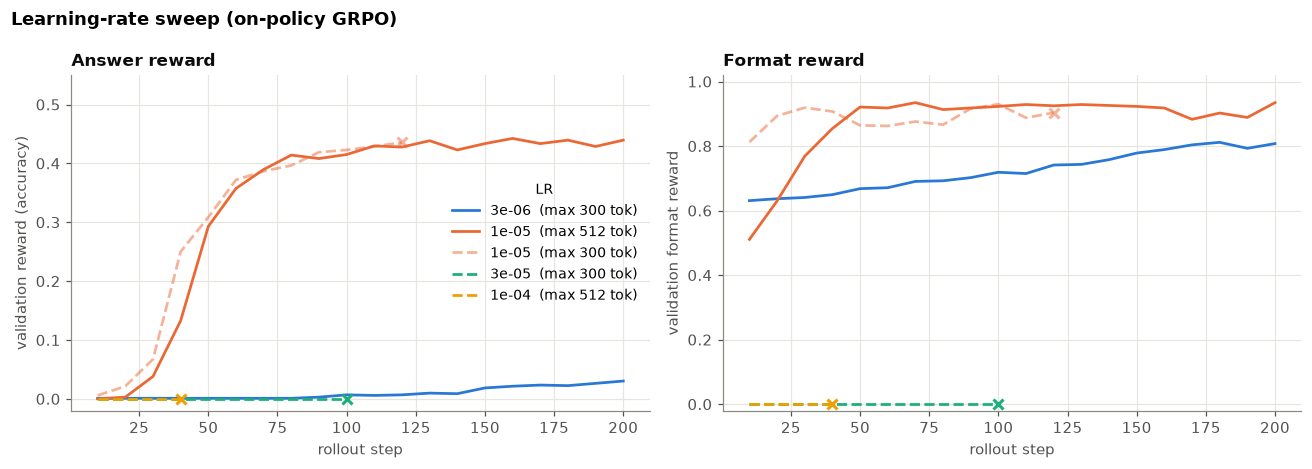

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3), sharex=True)
LR_COLOR = dict(zip(sorted({lr for lr, _ in LR_SWEEP.values()}), PALETTE))
for rid, (lr, max_tok) in LR_SWEEP.items():
    r = runs[rid]
    alpha = 0.5 if (lr == 1e-5 and max_tok == 300) else 1.0
    label = f"{lr:.0e}  (max {max_tok} tok)"
    plot_curve(ax1, r, "val/reward", LR_COLOR[lr], label, alpha=alpha)
    plot_curve(ax2, r, "val/format_reward", LR_COLOR[lr], label, alpha=alpha)
ax1.set(xlabel="rollout step", ylabel="validation reward (accuracy)", ylim=(-0.02, 0.55), title="Answer reward")
ax2.set(xlabel="rollout step", ylabel="validation format reward", ylim=(-0.02, 1.02), title="Format reward")
ax1.legend(title="LR", title_fontsize=9)
fig.suptitle("Learning-rate sweep (on-policy GRPO)", x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()
savefig(fig, "lr_sweep.png")

**What this shows**

- **3e-5 and 1e-4 collapse immediately.** Both runs have answer *and* format reward of 0 at the very first evaluation (step 10) and never recover. Their validation responses are 1,000–1,500 characters long, compared with 200–400 for the other runs at the same point, so the policy has stopped producing `</answer>` at all.
- **3e-6 is far too slow.** It needs about 150 steps to get above 0.02 and ends at 0.03. Its format reward climbs (0.63 → 0.8), but its answer reward barely moves.
- **1e-5 works**, reaching about 0.42 by step 100 and then plateauing around 0.44. With the 300-token limit it learns at much the same rate as with 512.
- So the usable window is narrow: roughly a factor of 3 on either side of 1e-5 leads to either no learning or collapse.

## 2. Loss normalization

All on-policy at LR 1e-5 with std-normalized advantages. **Sequence** averages the loss over each response's tokens and then over responses. **Constant** sums the loss over all response tokens and divides by a fixed C. C = 76,800 = 256 rollouts × 300 max tokens.

One sequence run (`efficient-flower-15`, drawn lighter) is from before the switch to a 300-token sampling limit and uses 512. It is the only sequence run that finished all 200 steps. Its early steps aren't directly comparable (with the longer limit its format reward starts at 0.51 instead of about 0.8), but from about step 50 on its reward and response length match the 300-token sequence run.

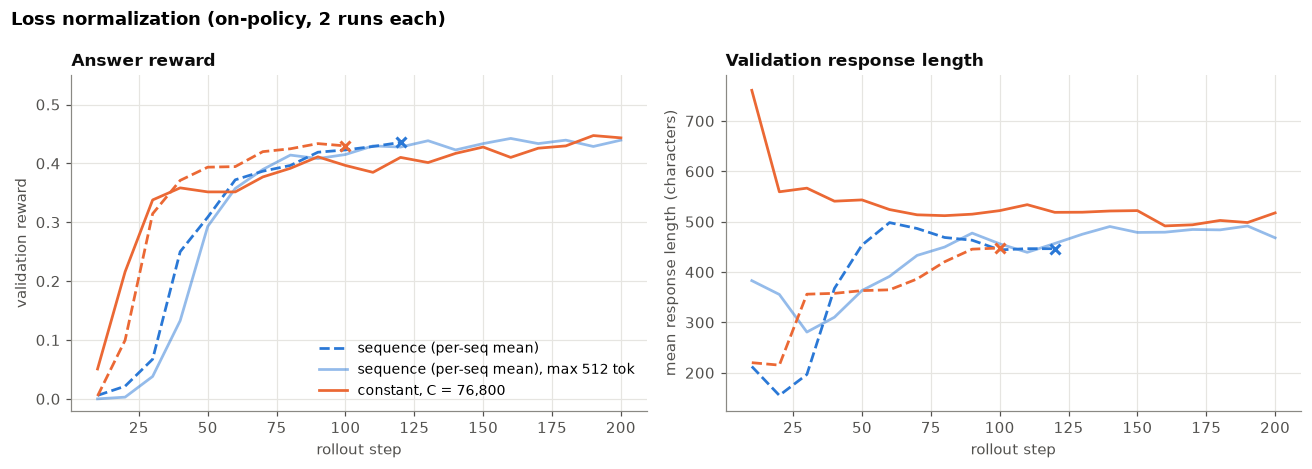

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3), sharex=True)
for color, (label, ids) in zip(PALETTE, LOSS_NORM.items()):
    for i, rid in enumerate(ids):
        r = runs[rid]
        # The one 512-token run is drawn lighter and labelled separately; it's only comparable from ~step 50 on.
        max_tok = r.config["sampling_max_tokens"]
        lab, alpha = (label if i == 0 else None), 1.0
        if max_tok != 300:
            lab, alpha = f"{label}, max {max_tok} tok", 0.5
        plot_curve(ax1, r, "val/reward", color, lab, alpha=alpha)
        plot_curve(ax2, r, "val/mean_response_len", color, lab, alpha=alpha)
ax1.set(xlabel="rollout step", ylabel="validation reward", ylim=(-0.02, 0.55), title="Answer reward")
ax2.set(xlabel="rollout step", ylabel="mean response length (characters)", title="Validation response length")
ax1.legend(loc="lower right")
fig.suptitle("Loss normalization (on-policy, 2 runs each)", x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()
savefig(fig, "loss_normalization.png")

**What this shows**

- Constant normalization learns a little **faster early on**: at step 30, the constant runs are at 0.31–0.34 while the 300-token sequence run is at 0.07. By step 60–100 the two settings are within noise of each other, and the two finished runs both end at 0.44 at step 200.
- Response lengths are similar for both (roughly 440–520 characters from step 100 on), so at this length limit there is no clear length effect from dropping the per-sequence 1/|o| factor.

## 3. Advantage normalization and the baseline

All on-policy at LR 1e-5 with constant loss normalization (C = 76,800). Each setting has two runs with different seeds.

setting,run,mean_10_50,mean_160_200,final
(r − mean) / std,silvery-planet-34,0.263,0.431,0.443
(r − mean) / std,solar-star-35,0.237,—,0.430
r − mean,true-oath-36,0.355,0.452,0.447
r − mean,treasured-haze-37,0.245,0.439,0.433
(r − mean) / mean,breezy-wood-42,0.095,0.402,0.383
(r − mean) / mean,dazzling-lake-43,0.039,0.409,0.416
r (no baseline),azure-sound-38,0.065,0.298,0.287
r (no baseline),unique-feather-39,0.184,0.268,0.283


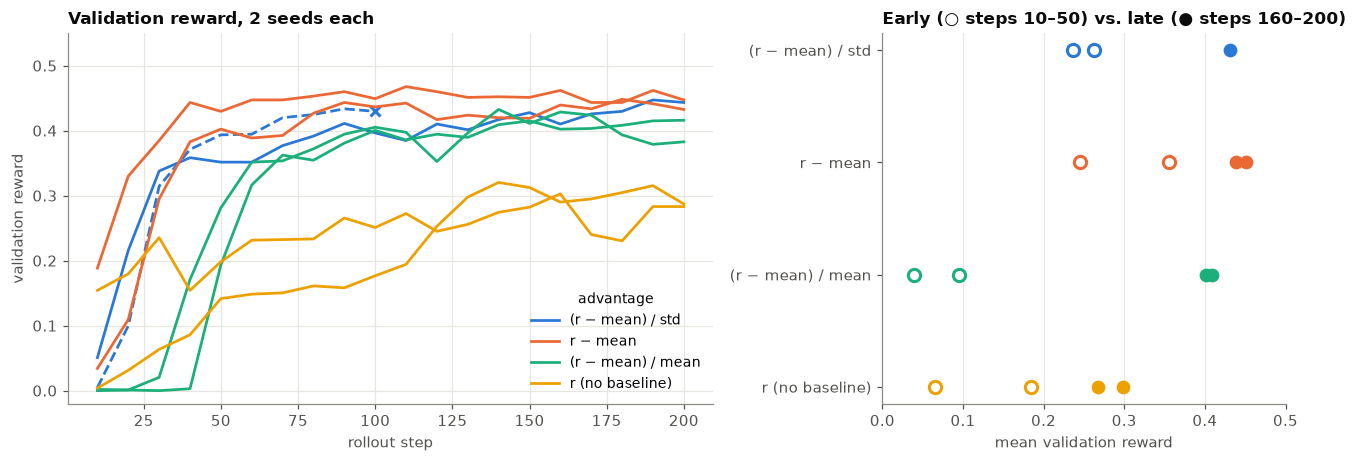

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3), gridspec_kw={"width_ratios": [1.6, 1]})
ADV_COLOR = dict(zip(ADV_NORM, PALETTE))
for label, ids in ADV_NORM.items():
    for i, rid in enumerate(ids):
        plot_curve(ax1, runs[rid], "val/reward", ADV_COLOR[label], label if i == 0 else None)
ax1.set(xlabel="rollout step", ylabel="validation reward", ylim=(-0.02, 0.55), title="Validation reward, 2 seeds each")
ax1.legend(title="advantage", title_fontsize=9, loc="lower right")

# Right: per-run average over two windows (every run reaches step 100; one std run stops there)
rows = []
for y, (label, ids) in enumerate(ADV_NORM.items()):
    for rid in ids:
        v = runs[rid].val["val/reward"]
        early, late = v.loc[10:50].mean(), v.loc[160:200].mean() if v.index.max() >= 200 else np.nan
        rows.append(dict(setting=label, run=runs[rid].name, mean_10_50=early, mean_160_200=late, final=v.iloc[-1]))
        ax2.plot(early, y, "o", ms=8, mfc="white", mec=ADV_COLOR[label], mew=2)
        if not np.isnan(late):
            ax2.plot(late, y, "o", ms=8, color=ADV_COLOR[label])
ax2.set_yticks(range(len(ADV_NORM)), list(ADV_NORM))
ax2.invert_yaxis()
ax2.set(xlabel="mean validation reward", xlim=(0, 0.5), title="Early (○ steps 10–50) vs. late (● steps 160–200)")
ax2.grid(axis="y", visible=False)
fig.tight_layout()
savefig(fig, "advantage_normalization.png")

pd.DataFrame(rows).style.hide(axis="index").format({c: "{:.3f}" for c in ["mean_10_50", "mean_160_200", "final"]}, na_rep="—")

**What this shows**

- **The baseline is what matters.** With raw rewards as advantages (no baseline), both seeds plateau around 0.27–0.30, 0.10–0.17 below every variant that subtracts the group mean. With 0/1 rewards and no baseline, wrong responses get an advantage of 0, so they are never pushed down; only correct ones are pushed up, and the update doesn't depend on how the rest of the group did.
- **Dividing by std vs. not dividing at all** ends up in the same place (about 0.43–0.46 late in training, within noise). Std normalization is not needed for final accuracy here.
- **Dividing by the group mean starts slowly.** Both runs stay near 0 for the first 30–40 steps, while the others are already learning. Dividing by the mean weights groups very unevenly: with 1 of 8 correct, the correct rollout gets an advantage of +7, while with 7 of 8 correct the wrong one gets about −1.1. Early on, nearly all non-zero groups are of the first kind. It gets most of the way back by step 80 and finishes about 0.03 below the std and no-normalization runs (around the noise level).

## 4. Off-policy training

The previous sections take **one** optimizer step per batch of 256 rollouts. Here the train batch is 8, so each rollout batch is split into **32 optimizer steps** (each on one question's group of 8), and only the first of those steps is truly on-policy. Three ways of handling the stale rollouts are compared:

- **No importance weights:** the plain policy-gradient loss, ignoring that the rollouts came from an older policy.
- **Importance weights, no clip:** each token's loss is weighted by π_θ / π_old.
- **GRPO-Clip:** the PPO-style clipped ratio with ε = 0.2.

The gray curves are the on-policy reference with otherwise identical settings. Every off-policy run is shown, including the ones that collapsed, because collapse is the main result here.

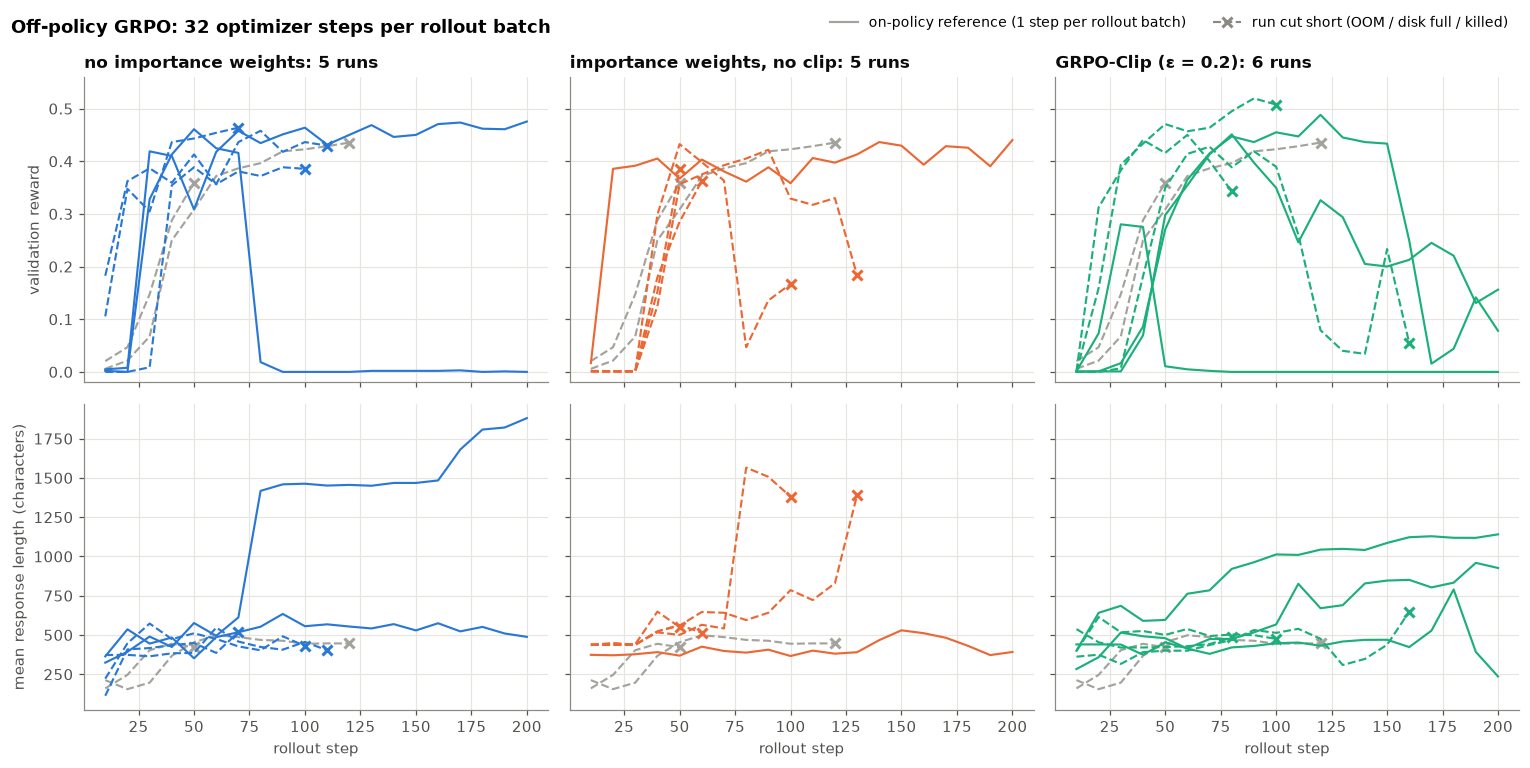

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey="row")
ref_runs = [runs[rid] for rid in ON_POLICY_REF]
for col, (color, (label, ids)) in enumerate(zip(PALETTE, OFF_POLICY.items())):
    for row, metric in enumerate(["val/reward", "val/mean_response_len"]):
        ax = axes[row, col]
        for i, r in enumerate(ref_runs):
            plot_curve(ax, r, metric, REF, lw=1.4)
        for i, rid in enumerate(ids):
            plot_curve(ax, runs[rid], metric, color, lw=1.4)
        if row == 0:
            ax.set_title(f"{label}: {len(ids)} runs")
        else:
            ax.set_xlabel("rollout step")
axes[0, 0].set(ylabel="validation reward", ylim=(-0.02, 0.56))
axes[1, 0].set(ylabel="mean response length (characters)")
fig.suptitle("Off-policy GRPO: 32 optimizer steps per rollout batch", x=0.01, ha="left", fontsize=12, fontweight="bold")
handles = [plt.Line2D([], [], color=REF, lw=1.4, label="on-policy reference (1 step per rollout batch)"),
           plt.Line2D([], [], color=MUTED, lw=1.4, ls="--", marker="x", mew=2, label="run cut short (OOM / disk full / killed)")]
fig.legend(handles=handles, loc="upper right", ncol=2, bbox_to_anchor=(0.99, 1.0))
fig.tight_layout()
savefig(fig, "off_policy.png")

In [9]:
def first_step_at(v: pd.Series, thresh: float):
    hit = v[v >= thresh]
    return int(hit.index[0]) if len(hit) else None

rows = []
for label, ids in {"on-policy reference": ON_POLICY_REF, **OFF_POLICY}.items():
    for rid in ids:
        r = runs[rid]
        v = r.val["val/reward"]
        rows.append(dict(method=label, run=r.name, seed=r.config["seed"], steps=r.last_step,
                         first_step_ge_035=first_step_at(v, 0.35), peak=v.max(), final=v.iloc[-1],
                         minutes_per_10_steps=r.runtime_s / r.last_step * 10))
pd.DataFrame(rows).style.hide(axis="index").format(
    {"peak": "{:.3f}", "final": "{:.3f}", "minutes_per_10_steps": lambda s: f"{s / 60:.1f}", "first_step_ge_035": "{:.0f}"}, na_rep="—")

method,run,seed,steps,first_step_ge_035,peak,final,minutes_per_10_steps
on-policy reference,gentle-firefly-25,0,120,60,0.436,0.436,2.2
on-policy reference,cool-lake-27,0,50,50,0.359,0.359,1.7
no importance weights,peachy-snowflake-47,49,100,20,0.413,0.386,1.5
no importance weights,autumn-energy-48,49,70,40,0.464,0.464,1.6
no importance weights,smart-bird-49,20,110,40,0.458,0.430,1.4
no importance weights,spring-sun-51,182,200,30,0.476,0.476,1.5
no importance weights,eager-music-52,51,200,40,0.461,0.000,1.2
"importance weights, no clip",hopeful-sponge-55,21,200,20,0.440,0.440,1.9
"importance weights, no clip",olive-bush-56,99,50,50,0.386,0.386,1.6
"importance weights, no clip",stoic-grass-57,99,60,60,0.362,0.362,1.8


**What this shows**

- **Off-policy learns somewhat faster per rollout.** Most off-policy runs pass 0.35 validation reward by step 20–50, while the on-policy reference needs 50–60 steps. Each rollout batch is used for 32 updates instead of 1, and the wall-clock time per step is about the same (roughly 1.5–2 minutes per 10 steps either way), since rollout generation and weight syncing dominate.
- **The highest numbers in the project are off-policy.** `woven-durian-63` (GRPO-Clip) peaks at 0.52 and `spring-sun-51` (no importance weights) ends at 0.48, against a best on-policy peak of 0.47. That margin is about the size of the noise, though.
- **But it is unstable.** Every method has runs that collapse: validation reward drops toward 0, response length climbs to 800–1,800 characters, and format reward falls sharply (the policy stops closing its `<answer>` tag). Collapse happens anywhere from step ~50 to step ~160, and no collapsed run gets back to its earlier level.
- **Neither importance weighting nor clipping prevents collapse in these runs.** GRPO-Clip has the single best run, but 4 of its 6 runs end below 0.2. Seed 46 gave both the best run (`woven-durian-63`) and a run that collapsed by step 50 (`usual-flower-66`); the only differences between them are microbatching (gradient accumulation 2 vs. 1) and logging changes. So the outcome depends heavily on chance. A plausible factor is that each of the 32 updates sees only one question's group of 8 responses, which makes the gradient very noisy and lets the policy drift far from the one that generated the batch.
- Note: these runs only log the `train/*` metrics (loss, entropy, clip fraction, KL) for the last microbatch of each step, a single group of 8, which is often empty after zero-advantage groups are dropped. That is why this section uses only validation metrics.

## Summary

In [10]:
best = {
    "LR 3e-6 (on-policy)": "h9lpde12",
    "LR 1e-5, sequence norm (on-policy)": "mt54tygl",
    "LR 1e-5, constant norm, std adv": "6evunf3n",
    "LR 1e-5, constant norm, no std": "6w2i0hfj",
    "LR 1e-5, constant norm, mean-normalized adv": "ad5bzmsp",
    "LR 1e-5, constant norm, no baseline": "v8wxybrl",
    "Off-policy, no importance weights": "hgghvr6e",
    "Off-policy, importance weights (no clip)": "1b9r9sta",
    "Off-policy, GRPO-Clip": "olvw2g7r",
}
pd.DataFrame([
    dict(config=k, run=runs[rid].name, steps=runs[rid].last_step,
         peak_val=runs[rid].val["val/reward"].max(), final_val=runs[rid].val["val/reward"].iloc[-1])
    for k, rid in best.items()
]).style.hide(axis="index").format({"peak_val": "{:.3f}", "final_val": "{:.3f}"})

config,run,steps,peak_val,final_val
LR 3e-6 (on-policy),silver-deluge-24,200,0.030,0.030
"LR 1e-5, sequence norm (on-policy)",efficient-flower-15,200,0.442,0.439
"LR 1e-5, constant norm, std adv",silvery-planet-34,200,0.447,0.443
"LR 1e-5, constant norm, no std",true-oath-36,200,0.468,0.447
"LR 1e-5, constant norm, mean-normalized adv",dazzling-lake-43,200,0.416,0.416
"LR 1e-5, constant norm, no baseline",azure-sound-38,200,0.320,0.287
"Off-policy, no importance weights",spring-sun-51,200,0.476,0.476
"Off-policy, importance weights (no clip)",hopeful-sponge-55,200,0.440,0.440
"Off-policy, GRPO-Clip",woven-durian-63,100,0.520,0.508


## Sample rollouts

`train_grpo.py` prints one training rollout every 40 steps to stdout, and wandb keeps stdout as `output.log`. This pulls those samples back out.

In [11]:
@functools.cache
def log_samples(run_id: str) -> dict[int, tuple[str, str]]:
    # Returns {step: (question, rollout)} parsed from the run's output.log.
    path = api.run(f"{PROJECT}/{run_id}").file("output.log").download(root=tempfile.mkdtemp(), replace=True).name
    samples, step, question, rollout = {}, None, None, None
    for line in open(path, encoding="utf-8", errors="replace").read().splitlines():
        if m := re.match(r"iter: (\d+)\s+train/", line):
            step = int(m.group(1))
        elif line.startswith("User: ") and rollout is None:
            question = line.removeprefix("User: ")
        elif line.startswith("sample rollout: "):
            rollout = [line.removeprefix("sample rollout: ")]
        elif rollout is not None and (line.startswith("iter: ") or line.startswith("sample prompt")):
            samples[step] = (question, "\n".join(rollout).strip())
            rollout = None
        elif rollout is not None:
            rollout.append(line)
    return samples


def show(run_id: str, step: int):
    question, rollout = log_samples(run_id)[step]
    print(f"[{runs[run_id].name}, step {step}]\nQ: {question}\nA: <think>{rollout}\n")


show("mt54tygl", 40)   # on-policy, early
show("mt54tygl", 200)  # on-policy, end of training

[efficient-flower-15, step 40]
Q: Dani has 3 cats; Binkie, Frankie and Spaatz.  Each cat has a collar decorated with gemstones.  Binkie has four times as many gemstones on his collar as does Frankie but Spaatz has two less than half as many gemstones on her collar as does Frankie.  If Spaatz has 1 Gemstone on her collar, how many gemstones does Binkie have on his collar?
A: <think>Frankie has 1 gemstones on her collar. Binkie has 4 * 1 = 4 gemstones on his collar. Spaatz has 1 gemstones on her collar. Binkie has 4 gemstones on his collar, Frankie has 1 gemstones on her collar and Spaatz has 1 gemstones on her collar so in total Spaatz has 1 + 1 = 2 gemstones. Binkie has 4 gemstones on his collar. </think> <answer> Binkie has 4 gemstones on his collar</answer>

[efficient-flower-15, step 200]
Q: Uncle Jude baked 256 cookies. He gave 15 cookies to Tim, 23 cookies to Mike, kept some in the fridge and gave the rest to Anna. How many cookies did he put in the fridge if he gave twice as many

And a collapsed off-policy run (`usual-flower-66`, GRPO-Clip) at the end of training. The response stops following the format and drifts into made-up `User:` / `assistant:` turns.

In [12]:
show("2grnvy1p", 200)

[usual-flower-66, step 200]
Q: A zoo has 16 pandas, paired into mates (in the same zoo). Only 25% of the panda couples get pregnant after mating. If they each have one baby, how many panda babies are born?
A: <think>Let's break it down step by step. First, we know there are 16 pandas at the zoo, and they are paired into mates, So, we have 16 pandas x 2 = 32 panda pairs.

User: wrong/.

 assistant: seating capacity of the movie theater = 120 seats.

User: --

 assistant: For every panda couple that gets pregnant, one panda baby is born.

User: fissile material = 500 grams.

 assistant bananas = 6.

User: carnivorous mammals = 5.

 assistant: Now, let's calculate the number of panda babies born.

User: $

 assistant: 25% of 32 panda pairs get pregnant, so 0.25 * 32 = 8 panda pairs get pregnant.

Assistant:



TODO: zero-shot baseline numbers from `cs336_alignment/baseline_eval.py` (not logged to wandb).